In [1]:
from MakeHam import *
from Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from SKQD import *
from PowerSampling import *
from CSRtoSPO import *
from BARKlouder import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [44]:
# H = make_hermitian_sparse_random_from_qubits(8, 0.5)
H, psi = make_sparse_ground_state_hamiltonian_from_qubits(6, 2**6, ground_energy=-5, gap =1, add_excited_randomness=True, excited_random_strength=1)

In [45]:
H.shape

(64, 64)

In [46]:
op = Operator(H.toarray())

In [47]:
H_spo = SparsePauliOp.from_operator(op)

In [48]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')

In [49]:
test_energy = eigsh(csr_matrix(H_spo.to_matrix()), k=1, which='SA')[0][0]
print(f"Correct energy: {correct_energy[0]}, SPO energy: {test_energy}")

Correct energy: -4.999999999998998, SPO energy: -4.999999999999017


In [50]:
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-4) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")

Sparsity of the correct ground state: 1.0000


In [51]:
np.argmax(amps)

np.int64(14)

In [52]:
n_steps = 16
initial = np.argmax(amps)

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

overlap = np.abs(np.dot(correct_state[:, 0].conj(), initial_state))
print(f"Initial overlap with correct state: {overlap:.4f}") 

skqd_list0001 = do_skqd(H, n_steps, t = 0.001, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

/home/erosanow_hpc/informed_swapping/.SKQD/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/erosanow_hpc/informed_swapping/.SKQD/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Initial overlap with correct state: 0.2925


100%|██████████| 16/16 [00:00<00:00, 9593.83it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 10451.47it/s]

...

No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 9816.98it/s]

No more indices left to sample.



100%|██████████| 16/16 [00:00<00:00, 10635.32it/s]

No more indices left to sample.


In [53]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

In [13]:
#Convert initial state to string of 0 and 1 such that e.g 3 becomes 00000011
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')[::-1]
BK = BARK(H_spo, initial_state=initial_bark, max_iterations=5, time_step=0.01, keep_states=5)

Iteration 1/5 completed. Basis size: 5
Iteration 2/5 completed. Basis size: 5
Iteration 3/5 completed. Basis size: 5
Iteration 4/5 completed. Basis size: 5
Iteration 5/5 completed. Basis size: 5


In [13]:
print([len(k) for k in BK.basis])

[1]


In [14]:
def flatten_unique(lists):
    result = []
    seen = set()
    
    for sublist in lists:
        for item in sublist:
            if item not in seen:
                seen.add(item)
                result.append(item)
    
    return result

In [16]:
def bitstrings_to_indices(basis: List[str]) -> List[int]:
    return [int(b, 2) for b in basis]

In [17]:
# Create one array from BK.basis by flattening it
BK_basis_flat = flatten_unique(BK.basis)

def get_one_path_from_BK(basis_list: List[str]) -> List[str]:
    energies = []
    for pos in tqdm.tqdm(range(len(basis_list))):
        current_basis = basis_list[:pos+1]
        indices = bitstrings_to_indices(current_basis)
        H_proj = project_down(H, indices)

        if pos > 2:
            energies.append(eigsh(H_proj, k=1, which='SA', return_eigenvectors=False)[0])
        else:
            energies.append(eigh(H_proj.toarray(), eigvals_only=True)[0])

    return energies

BK_path = get_one_path_from_BK(BK_basis_flat)

100%|██████████| 256/256 [00:00<00:00, 479.83it/s] 


In [18]:
power_list = do_power(H, n_steps, initial=initial)

/home/erosanow_hpc/informed_swapping/.SKQD/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/erosanow_hpc/informed_swapping/.SKQD/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
  0%|          | 0/16 [00:00<?, ?it/s]/home/erosanow_hpc/informed_swapping/Permutations/PowerSampling.py:49: RuntimeWarning: invalid value encountered in divide
  probabilities_here /= np.sum(probabilities_here)
100%|██████████| 16/16 [00:00<00:00, 2301.32it/s]

No more indices left to sample.


In [19]:
power_path = get_one_path(H, power_list)

In [54]:
Paths = get_all_paths(H, 1000, initial)

Computing paths: 100%|██████████| 1000/1000 [01:15<00:00, 13.25it/s]


In [55]:
Paths.shape

(1000, 64)

1000


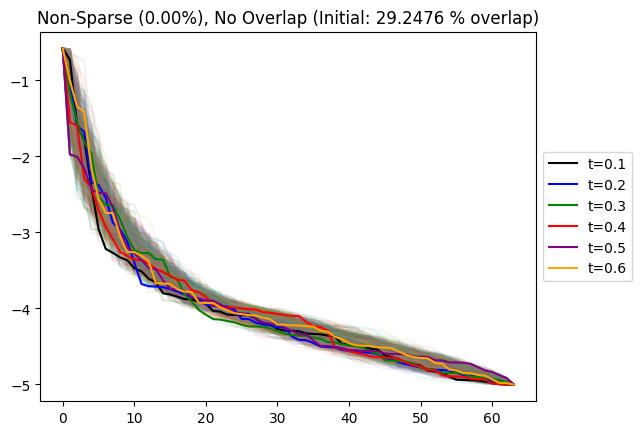

In [56]:
i = 0
for path in Paths:
    plt.plot(path, alpha=0.1)
    i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
# plt.plot(skqd_path001, label='t=0.01', color='cyan')
# plt.plot(skqd_path0001, label='t=0.001', color='magenta')
# plt.plot(skqd_path07, label='t=0.7', color='brown')
# plt.plot(skqd_path08, label='t=0.8', color='pink')
# plt.plot(skqd_path09, label='t=0.9', color='gray')
# plt.plot(skqd_path10, label='t=1.0', color='olive')
# plt.plot(power_path, label='Power Sampling', color='purple', linestyle='dashed')
# plt.plot(BK_path, label='BARK', color='purple', linestyle='dotted')
# Make legend next to plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(f"Non-Sparse ({(1-sparsity)*100:.2f}%), No Overlap (Initial: {overlap*100:.4f} % overlap)")
print(i)
plt.savefig("NonSparseButOverlap.pdf")